# Missing values in data set

- Sometimes is better to delete rows with missing values. It depends which data is missing and how much data in row is missing.
- If missing data is easy to count, for example if price is missing, we can set mediana in this value.
- We can also train model to fill in the missing values.
- Another method is to use interpolation (time series) or add a new category, such as missing (categorical variables).

Everything is depends on situation and usage of data.

### **Important!**

To fill in missing values we do calculations on training data set, not testing data set. This prevents information leaks from the test data set.

In [662]:
import numpy as np
import pandas as pd
import sklearn

sklearn.__version__

'1.8.0'

Generate data with missing values

In [663]:
data = {
    'size': [np.nan, 'M', 'L', 'XL', 'XXL', 'M'],
    'color': ['red', 'blue', np.nan, 'green', 'yellow', 'black'],
    'gender': ['male', 'female', 'female', np.nan, 'male', 'male'],
    'price': [199.0, 89.0, np.nan, 129.0, 79.0, 89.0],
    'weight': [500, 450, 300, np.nan, 410, np.nan],
    'bought': ['yes', 'no', 'yes', 'no', 'yes', 'no']
}

df_raw = pd.DataFrame(data)
df_raw

,size,color,gender,price,weight,bought
0,NaN,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,NaN,female,NaN,300.0,yes
3,XL,green,NaN,129.0,NaN,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,NaN,no


Create data copy.

In [664]:
df_train = df_raw.copy()
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   size    5 non-null      str    
 1   color   5 non-null      str    
 2   gender  5 non-null      str    
 3   price   5 non-null      float64
 4   weight  4 non-null      float64
 5   bought  6 non-null      str    
dtypes: float64(2), str(4)
memory usage: 420.0 bytes


Search for missing data.

In [665]:
# show missing values - if miss we will see 'true'
df_train.isnull()

,size,color,gender,price,weight,bought
0,True,False,False,False,False,False
1,False,False,False,False,False,False
2,False,True,False,True,False,False
3,False,False,True,False,True,False
4,False,False,False,False,False,False
5,False,False,False,False,True,False


In [666]:
# count missing values per column
df_train.isnull().sum()

size      1
color     1
gender    1
price     1
weight    2
bought    0
dtype: int64

In [667]:
# count all missing values in the dataset
df_train.isnull().sum().sum()

np.int64(6)

In [668]:
# check percentage of missing values per column
df_train.isnull().sum() / len(df_train)

size      0.166667
color     0.166667
gender    0.166667
price     0.166667
weight    0.333333
bought    0.000000
dtype: float64

## Fill in missing values - SimpleImputer

## SimpleImputer Strategies

The `SimpleImputer` class from scikit-learn provides several strategies for handling missing values:

- **mean**: Replaces missing values with the mean of the column. Only works with numerical data.
- **median**: Replaces missing values with the median of the column. Only works with numerical data.
- **most_frequent**: Replaces missing values with the most frequent value in the column. Works with both numerical and categorical data.
- **constant**: Replaces missing values with a specified constant value. Requires the `fill_value` parameter.

In [669]:
from sklearn.impute import SimpleImputer

# strategy: 'mean', 'median', 'most_frequent' or 'constant'
# mean is only for numerical data, most_frequent can be used for both numerical and categorical data
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(df_train[['weight']])

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [670]:
# check what value was calculated for imputation
imputer.statistics_

array([415.])

In [671]:
# apply imputer to our data
imputer.transform(df_train[['weight']])

array([[500.],
       [450.],
       [300.],
       [415.],
       [410.],
       [415.]])

In [672]:
# to do in place imputation we can assign the transformed values back to the original dataframe
df_train['weight'] = imputer.transform(df_train[['weight']])
df_train

,size,color,gender,price,weight,bought
0,NaN,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,NaN,female,NaN,300.0,yes
3,XL,green,NaN,129.0,415.0,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,415.0,no


In [673]:
# strategy 'constant' can be used to fill missing values with a constant value of our choice
imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=99.0)
df_train['price'] = imputer.fit_transform(df_train[['price']])

In [674]:
imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='L')
df_train['size'] = imputer.fit_transform(df_train[['size']]).ravel()

# ravel() is used to convert the 2D array returned by fit_transform into a 1D array, which can be assigned back to the 'size' column of the dataframe.

In [675]:
df_train

,size,color,gender,price,weight,bought
0,L,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,NaN,female,99.0,300.0,yes
3,XL,green,NaN,129.0,415.0,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,415.0,no


In [676]:
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
df_train['color'] = imputer.fit_transform(df_train[['color']]).ravel()
df_train['gender'] = imputer.fit_transform(df_train[['gender']]).ravel()
df_train

,size,color,gender,price,weight,bought
0,L,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,black,female,99.0,300.0,yes
3,XL,green,male,129.0,415.0,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,415.0,no


## Some posibilities to check missing data

In [677]:
df = df_raw.copy()
df

,size,color,gender,price,weight,bought
0,NaN,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,NaN,female,NaN,300.0,yes
3,XL,green,NaN,129.0,NaN,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,NaN,no


In [678]:
# check how many values in category is null
df.isnull().sum()

size      1
color     1
gender    1
price     1
weight    2
bought    0
dtype: int64

In [679]:
# check how many missing values we have in the 'size' column with mask in binary
pd.isnull(df['size'])

0     True
1    False
2    False
3    False
4    False
5    False
Name: size, dtype: bool

In [680]:
# shows only rows where 'size' is null
df[pd.isnull(df['size'])]

,size,color,gender,price,weight,bought
0,NaN,red,male,199.0,500.0,yes


In [681]:
# shows only rows where 'size' is not null
df[~pd.isnull(df['size'])]

,size,color,gender,price,weight,bought
1,M,blue,female,89.0,450.0,no
2,L,NaN,female,NaN,300.0,yes
3,XL,green,NaN,129.0,NaN,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,NaN,no


In [682]:
df

,size,color,gender,price,weight,bought
0,NaN,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,NaN,female,NaN,300.0,yes
3,XL,green,NaN,129.0,NaN,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,NaN,no


## fillna() method

fillna() method - fill mising data with const value: '0', 'no_data' or what we want.

In [683]:
df.fillna(value='no_data')

,size,color,gender,price,weight,bought
0,no_data,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,no_data,female,no_data,300.0,yes
3,XL,green,no_data,129.0,no_data,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,no_data,no


In [684]:
df

,size,color,gender,price,weight,bought
0,NaN,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,NaN,female,NaN,300.0,yes
3,XL,green,NaN,129.0,NaN,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,NaN,no


In [685]:
# df['size'].fillna(value='L', inplace=True)
# better option: 
df['size'] = df['size'].fillna(value='L') 
df

,size,color,gender,price,weight,bought
0,L,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,NaN,female,NaN,300.0,yes
3,XL,green,NaN,129.0,NaN,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,NaN,no


## dropna() method

dropna() method - creates a new DataFrame without the missing values, to change our DataFrame we need to assign the results back.
- axis="columns" - drop columns where at least one element is missing
- how="all" - drop the rows where all elements are missing.
- tresh="2" - keep only the rows with at least 2 non-NA values.
- subset=["coumn-name"] - define in which columns to look for missing values.

In [686]:
df.dropna()
df_dropna = df.dropna()
df_dropna

,size,color,gender,price,weight,bought
0,L,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
4,XXL,yellow,male,79.0,410.0,yes


In [687]:
df.dropna(thresh=2)

,size,color,gender,price,weight,bought
0,L,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,NaN,female,NaN,300.0,yes
3,XL,green,NaN,129.0,NaN,no
4,XXL,yellow,male,79.0,410.0,yes
5,M,black,male,89.0,NaN,no


In [688]:
df.dropna(subset=['weight'])

,size,color,gender,price,weight,bought
0,L,red,male,199.0,500.0,yes
1,M,blue,female,89.0,450.0,no
2,L,NaN,female,NaN,300.0,yes
4,XXL,yellow,male,79.0,410.0,yes


In [689]:
df.dropna(axis="columns")

,size,bought
0,L,yes
1,M,no
2,L,yes
3,XL,no
4,XXL,yes
5,M,no


## Missing data in time series.

In [690]:
data = {'price': [108, 109, 110, 110, 109, np.nan, np.nan, 112, 111, 111]}
date_range = pd.date_range(start='2023-01-01 09:00', end='2023-01-01 18:00', periods=10)

df = pd.DataFrame(data, index=date_range)
df

,price
2023-01-01 09:00:00,108.0
2023-01-01 10:00:00,109.0
2023-01-01 11:00:00,110.0
2023-01-01 12:00:00,110.0
2023-01-01 13:00:00,109.0
2023-01-01 14:00:00,NaN
2023-01-01 15:00:00,NaN
2023-01-01 16:00:00,112.0
2023-01-01 17:00:00,111.0
2023-01-01 18:00:00,111.0


In [691]:
# create plot - libraries for plotting time series data
from pandas.plotting import register_matplotlib_converters
import matplotlib.pyplot as plt
import seaborn as sns
register_matplotlib_converters()
sns.set()

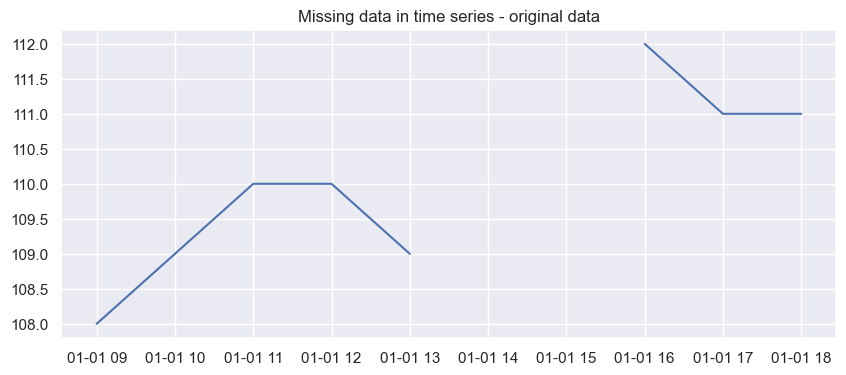

In [692]:
plt.figure(figsize=(10, 4))
plt.title('Missing data in time series - original data')
_ = plt.plot(df.price)

In [693]:
# plotly is another library for plotting time series data, it is interactive and can be used in jupyter notebooks
import plotly.express as px

df_plotly = df.reset_index()
px.line(df_plotly, 'index', 'price', width=600, height=400, title='Missing data in time series - original data')

### Methods to clean missing data:
- `dropna()` - is the most straightforward approach—it simply removes rows or columns containing missing values. This works well when you have a large dataset with relatively few missing values, or when the missing data represents a small fraction of your records.
- *fill missing values with 0* - is a simple imputation strategy that works best when zero is a meaningful value for your domain, this approach can distort statistical measures like the mean or standard deviation, and it may introduce bias if zeros aren't truly representative of the missing values
- *fill missing values with mean* - is a statistical approach that preserves the overall distribution and central tendency of your data, this method is particularly useful for numerical features and minimizes the impact on aggregate statistics
- *fill missing values with interpolation* - estimates missing values based on surrounding data points, making it ideal for time-series or sequential data, methods like linear interpolation draw a line between known values and estimate points in between, while polynomial or spline interpolation creates smoother curves
- *forward and backward fill* - Forward fill (ffill()) copies the last known value forward to fill subsequent missing entries, while backward fill (bfill()) copies the next known value backward, these methods are especially effective for time-series data where values tend to persist or change gradually over time, they preserve the temporal or sequential nature of your dataset

In [694]:
# drop missing values and plot again
df_plotly = df_plotly.dropna()
px.line(df_plotly, 'index', 'price', width=600, height=400, title='Missing data in time series - after dropping missing values')

In [695]:
# fill missing values with 0 and plot again
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].fillna(0)
px.line(df_plotly, x='index', y='price_fill', title='Missing data in time series - after filling missing values with 0', width=800, height=400)

In [696]:
# fill missing values with mean and plot again
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].fillna(df_plotly['price'].mean())
px.line(df_plotly, x='index', y='price_fill', title='Missing data in time series - after filling missing values with mean', width=800, height=400)

In [697]:
# fill missing values with interpolation and plot again
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].interpolate()
px.line(df_plotly, x='index', y='price_fill', title='Missing data in time series - after filling missing values with interpolation', width=800, height=400)

In [698]:
# fill missing values with forward fill and plot again
# forward fill - fills missing values with the last known value
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].ffill()
px.line(df_plotly, x='index', y='price_fill', title='Missing data in time series - after filling missing values with forward fill', width=800, height=400)

In [699]:
# fill missing values with backward fill and plot again 
# backward fill - fills missing values with the next known value
df_plotly = df.reset_index()
df_plotly['price_fill'] = df_plotly['price'].bfill()
px.line(df_plotly, x='index', y='price_fill', title='Missing data in time series - after filling missing values with backward fill', width=800, height=400)

## Summary

Missing data is a critical preprocessing step in machine learning and data analysis that dramatically affects model performance and data quality.

### Methods to Identify Missing Data
- **`isnull()`** - Returns a boolean mask showing which values are null
- **`isnull().sum()`** - Counts missing values per column
- **`isnull().sum().sum()`** - Total count of all missing values
- **`isnull().sum() / len(df)`** - Calculates percentage of missing values per column

### Filtering Rows with Missing Data
- **`pd.isnull(df['column'])`** - Shows rows with null values in specific column
- **`df[pd.isnull(df['column'])]`** - Returns rows where column is null
- **`df[~pd.isnull(df['column'])]`** - Returns rows where column is NOT null

### SimpleImputer Strategies
The scikit-learn `SimpleImputer` class provides four main strategies:

| Strategy | Use Case | Applicable Data Types |
|----------|----------|----------------------|
| **mean** | Replaces with column mean | Numerical only |
| **median** | Replaces with column median | Numerical only |
| **most_frequent** | Replaces with most common value | Numerical & Categorical |
| **constant** | Replaces with fixed value | All types |

### Implementation Pattern
```python
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(df[['column']])
df['column'] = imputer.transform(df[['column']])
```

#### 1. **dropna()** - Drop Rows
- Simplest method
- **Risk:** Significant data loss with many missing values
- **Best for:** Large datasets with sparse nulls

#### 2. **Fill with 0**
- Simple constant imputation
- **Risk:** Distorts statistics; 0 may not be meaningful
- **Best for:** When zero represents actual absence (e.g., no sales)

#### 3. **Fill with Mean**
- Statistical approach using column average
- **Risk:** Reduces variance; ignores variable relationships
- **Best for:** Numerical columns with random missing patterns

#### 4. **Interpolation**
- Estimates missing values from surrounding data points
- **Linear interpolation:** Draws lines between known points
- **Polynomial/Spline interpolation:** Creates smooth curves
- **Best for:** Time series where trends are continuous

#### 5. **Forward/Backward Fill**
- **Forward Fill (ffill()):** Copies last known value forward
- **Backward Fill (bfill()):** Copies next known value backward
- **Best for:** Time series where values persist gradually

---

### Key Takeaways
- Always inspect and understand missing data patterns first.
- Perform transformations on training data only.
- Choose methods aligned with your data characteristics.  
- Document your missing value handling strategy.
- Validate that your chosen method doesn't introduce bias.
- Monitor model performance to assess imputation quality.